# DSA_04 — Forecast & Peak-Risk View Prototypes

**Purpose.** Validate the primary decision-support visual encodings before
Streamlit deployment: demand heatmap, Peak-Risk heatmap, 24-hour demand lines,
and risk timeline.

In [1]:
# Import libraries
from pathlib import Path
import sys, yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG = PROJECT_ROOT / "configs" / "decision_support_app.yaml"
CONFIG

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/decision_support_app.yaml')

In [3]:
cfg = yaml.safe_load(
    (PROJECT_ROOT / "configs" / "decision_support_app.yaml")
    .read_text(encoding="utf-8")
)

In [4]:
from src.ontario_peak_risk.decision_support.backend import DemoRepository

In [5]:
repo = DemoRepository(cfg, PROJECT_ROOT)
origin = repo.available_origins[0]
data = repo.prediction_slice(origin)

In [6]:
import matplotlib.pyplot as plt

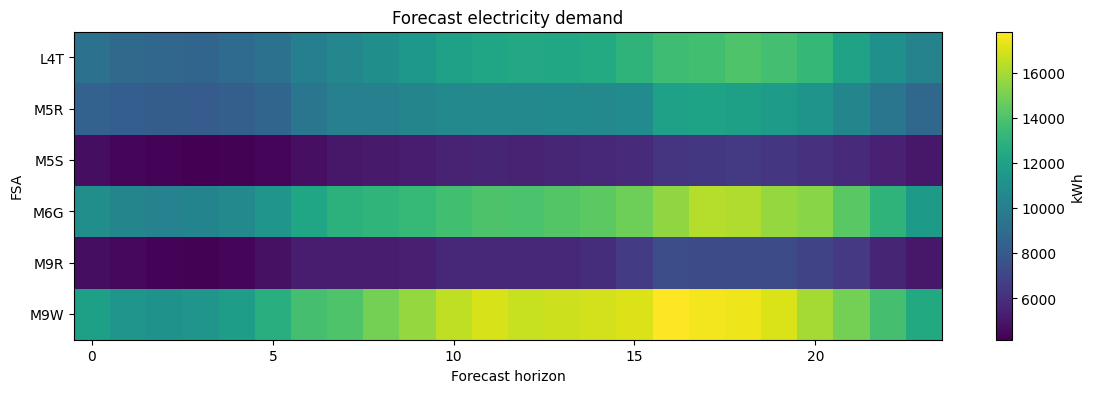

In [7]:
# Forecast electricity demand
demand_matrix = data.pivot(
    index="fsa",
    columns="horizon",
    values="forecast_consumption_kwh",
)
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(demand_matrix.values, aspect="auto")
ax.set_yticks(range(len(demand_matrix.index)))
ax.set_yticklabels(demand_matrix.index)
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("FSA")
ax.set_title("Forecast electricity demand")
fig.colorbar(im, ax=ax, label="kWh")
plt.show()

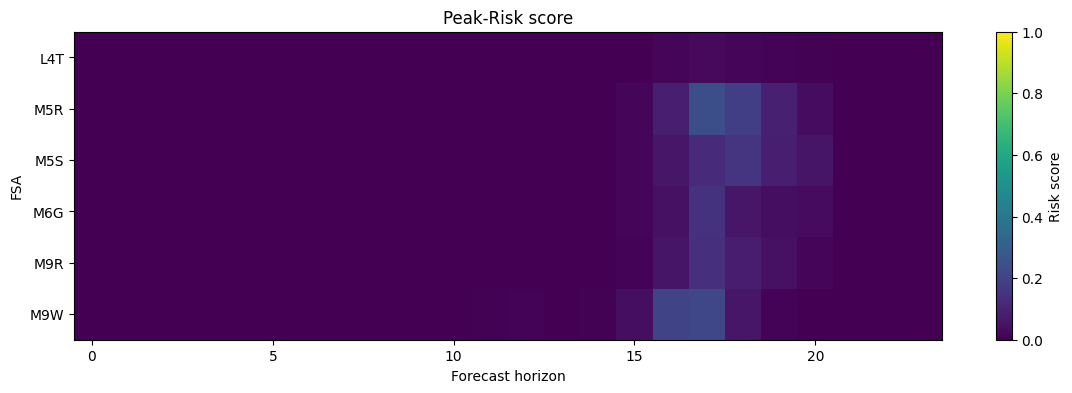

In [8]:
# Peak-Risk score
risk_matrix = data.pivot(
    index="fsa",
    columns="horizon",
    values="peak_risk_score",
)
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(risk_matrix.values, aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(risk_matrix.index)))
ax.set_yticklabels(risk_matrix.index)
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("FSA")
ax.set_title("Peak-Risk score")
fig.colorbar(im, ax=ax, label="Risk score")
plt.show()

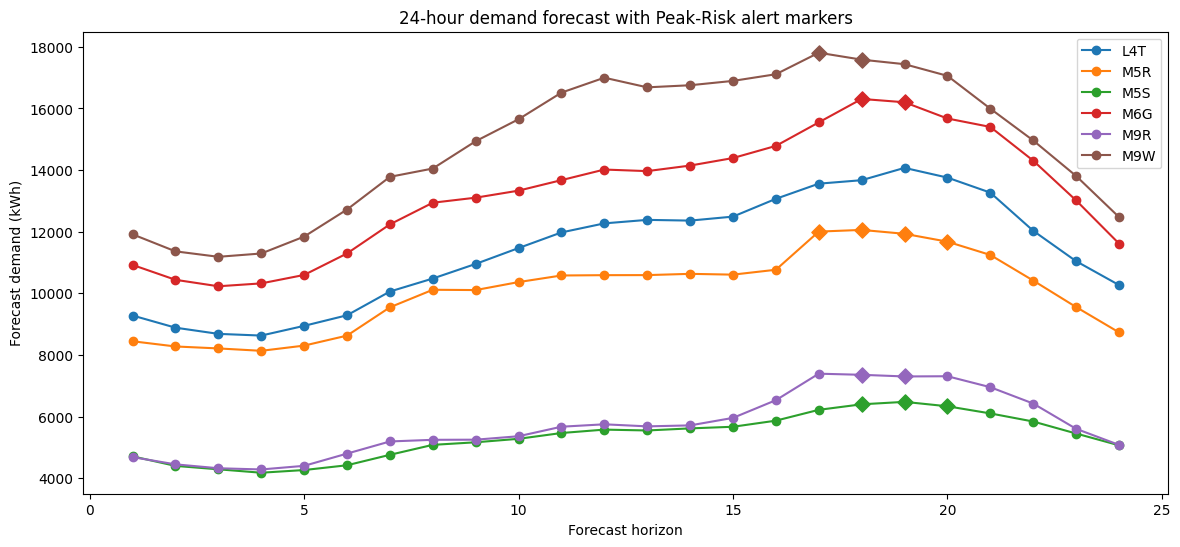

DSA_04 RESULT: COMPLETE


In [9]:
# 24-hour demand forecast with Peak-Risk alert markers
fig, ax = plt.subplots(figsize=(14, 6))
for fsa, group in data.groupby("fsa"):
    group = group.sort_values("horizon")
    ax.plot(
        group["horizon"],
        group["forecast_consumption_kwh"],
        marker="o",
        label=fsa,
    )
    alerts = group[group["peak_alert"].astype(bool)]
    ax.scatter(
        alerts["horizon"],
        alerts["forecast_consumption_kwh"],
        marker="D",
        s=60,
    )

ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Forecast demand (kWh)")
ax.set_title("24-hour demand forecast with Peak-Risk alert markers")
ax.legend()
plt.show()

print("DSA_04 RESULT: COMPLETE")